# 04b — InSAR Coherence Change Detection

SAR amplitude change (notebook 04) showed negligible differences between
Destroyed / Damaged / Unaffected parcels (~0.3 dB vs ~3 dB speckle noise).

**Coherence** measures the phase stability between two coregistered SAR
acquisitions.  Intact buildings are strong coherent scatterers (γ ≈ 0.7–0.9);
destroyed structures lose phase consistency (γ ≈ 0.1–0.3).  The expected
coherence *drop* (~0.4–0.6) is an order of magnitude above amplitude noise.

We use **OPERA CSLC** (Coregistered Single-Look Complex) products from
Sentinel-1 Track T056, burst 118973-IW1:

| Date | Role | File |
|------|------|------|
| 2021-12-19 | Pre-fire | `OPERA_…20211219…S1A_VV_v1.1.h5` |
| 2021-12-31 | Post-fire (day of fire) | `OPERA_…20211231…S1A_VV_v1.1.h5` |

Both are geocoded to EPSG:32613 (UTM 13N) at 5 m × 10 m pixel spacing on
identical grids — no coregistration needed.

In [1]:
import numpy as np
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path
from scipy.ndimage import uniform_filter
from rasterio.transform import from_bounds as transform_from_bounds
from rasterstats import zonal_stats
import rasterio
from rasterio.crs import CRS

plt.rcParams["figure.dpi"] = 120

## 1 — Load OPERA CSLC SLC chips over the AOI

In [2]:
CSLC_DIR = Path("../data/raw/sentinel1/cslc")
PRE_FILE  = sorted(CSLC_DIR.glob("*20211219*"))[0]
POST_FILE = sorted(CSLC_DIR.glob("*20211231*"))[0]

# AOI in EPSG:4326 → convert to UTM 13N (EPSG:32613)
from pyproj import Transformer
AOI_WGS84 = [-105.23, 39.915, -105.12, 39.98]  # [west, south, east, north]
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32613", always_xy=True)
aoi_west, aoi_south = to_utm.transform(AOI_WGS84[0], AOI_WGS84[1])
aoi_east, aoi_north = to_utm.transform(AOI_WGS84[2], AOI_WGS84[3])
print(f"AOI UTM bounds: W={aoi_west:.0f}  S={aoi_south:.0f}  E={aoi_east:.0f}  N={aoi_north:.0f}")

def load_cslc_chip(h5_path, aoi_bounds):
    """Load a complex SLC chip from an OPERA CSLC HDF5 file, clipped to AOI."""
    w, s, e, n = aoi_bounds
    with h5py.File(h5_path, "r") as f:
        x = f["/data/x_coordinates"][:]
        y = f["/data/y_coordinates"][:]
        # Find pixel indices for AOI
        col_mask = (x >= w) & (x <= e)
        row_mask = (y >= s) & (y <= n)
        c0, c1 = np.where(col_mask)[0][[0, -1]]
        r0, r1 = np.where(row_mask)[0][[0, -1]]
        slc = f["/data/VV"][r0:r1+1, c0:c1+1]
        x_chip = x[c0:c1+1]
        y_chip = y[r0:r1+1]
    return slc, x_chip, y_chip

slc_pre,  x_coords, y_coords = load_cslc_chip(PRE_FILE,  (aoi_west, aoi_south, aoi_east, aoi_north))
slc_post, _, _               = load_cslc_chip(POST_FILE, (aoi_west, aoi_south, aoi_east, aoi_north))

print(f"SLC chip shape: {slc_pre.shape}  dtype: {slc_pre.dtype}")
print(f"Valid pixels pre:  {np.isfinite(slc_pre).sum() / slc_pre.size:.1%}")
print(f"Valid pixels post: {np.isfinite(slc_post).sum() / slc_post.size:.1%}")

AOI UTM bounds: W=480343  S=4418348  E=489754  N=4425544
SLC chip shape: (719, 1882)  dtype: complex64
Valid pixels pre:  100.0%
Valid pixels post: 100.0%


## 2 — Compute InSAR coherence

Coherence γ is estimated with a spatial averaging window:

$$\gamma = \frac{|\langle s_1 \cdot s_2^* \rangle|}{\sqrt{\langle|s_1|^2\rangle \cdot \langle|s_2|^2\rangle}}$$

We use a 5×5 pixel window (~25 m × 50 m), balancing resolution and estimation variance.

In [3]:
def compute_coherence(slc1, slc2, win=5):
    """Estimate interferometric coherence with a uniform spatial averaging window."""
    s1 = np.where(np.isfinite(slc1), slc1, 0)
    s2 = np.where(np.isfinite(slc2), slc2, 0)
    # Cross-spectrum and power (averaged over window)
    cross_real = uniform_filter(np.real(s1 * np.conj(s2)), win)
    cross_imag = uniform_filter(np.imag(s1 * np.conj(s2)), win)
    cross = cross_real + 1j * cross_imag
    pow1 = uniform_filter(np.abs(s1)**2, win)
    pow2 = uniform_filter(np.abs(s2)**2, win)
    denom = np.sqrt(pow1 * pow2)
    coh = np.where(denom > 0, np.abs(cross) / denom, 0)
    # Mask invalid pixels
    valid = np.isfinite(slc1) & np.isfinite(slc2)
    coh[~valid] = np.nan
    return coh.astype(np.float32)

coherence = compute_coherence(slc_pre, slc_post, win=5)
print(f"Coherence shape: {coherence.shape}")
print(f"Coherence range: {np.nanmin(coherence):.3f} – {np.nanmax(coherence):.3f}")
print(f"Coherence mean:  {np.nanmean(coherence):.3f}")

Coherence shape: (719, 1882)
Coherence range: 0.001 – 0.998
Coherence mean:  0.587


## 3 — Visualise the coherence map

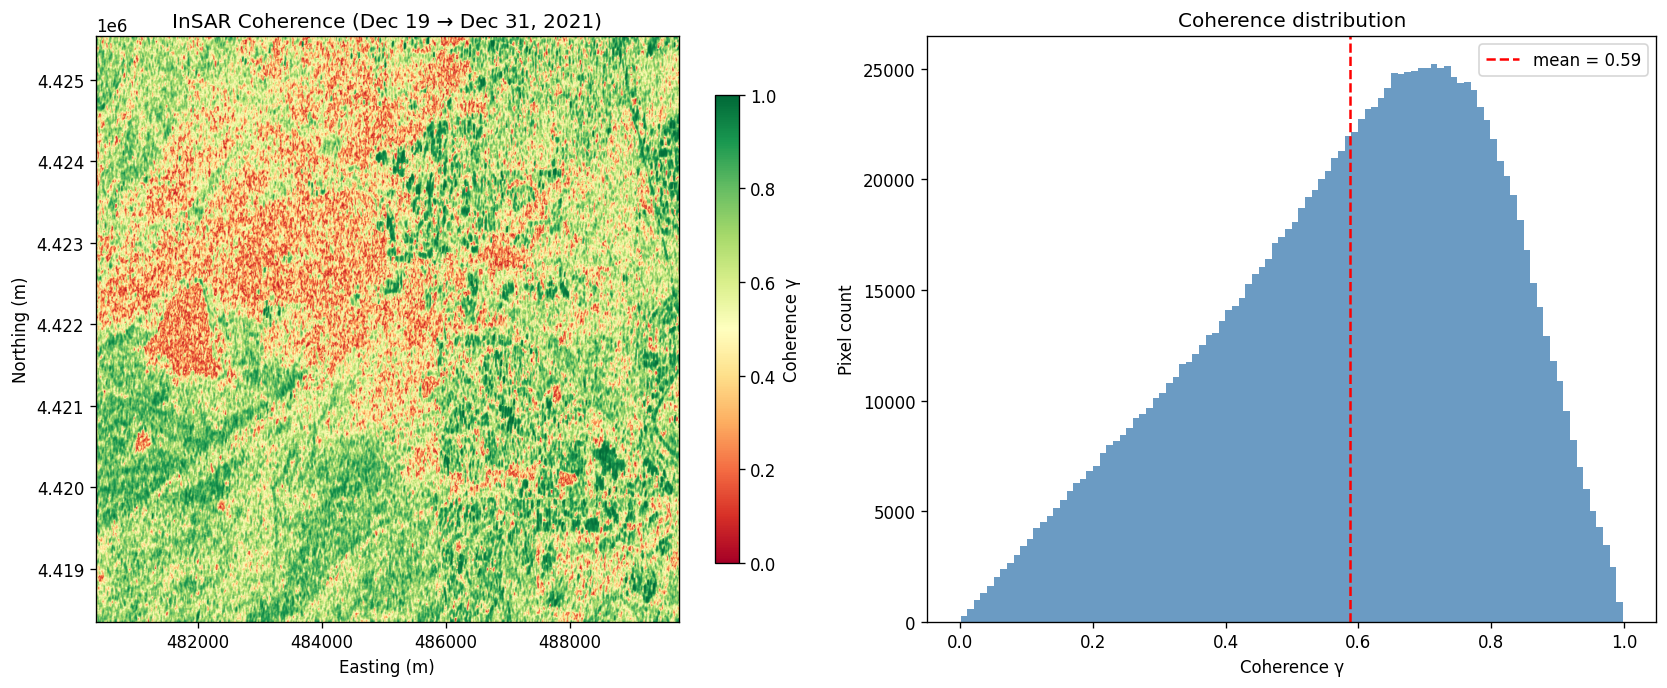

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coherence map
extent = [x_coords[0], x_coords[-1], y_coords[-1], y_coords[0]]
im = axes[0].imshow(coherence, cmap="RdYlGn", vmin=0, vmax=1, extent=extent, aspect="auto")
axes[0].set_title("InSAR Coherence (Dec 19 → Dec 31, 2021)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
plt.colorbar(im, ax=axes[0], label="Coherence γ", shrink=0.8)

# Histogram
valid_coh = coherence[np.isfinite(coherence)].ravel()
axes[1].hist(valid_coh, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[1].axvline(np.nanmean(coherence), color="red", ls="--", label=f"mean = {np.nanmean(coherence):.2f}")
axes[1].set_xlabel("Coherence γ")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Coherence distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4 — Load ground truth parcels and compute zonal coherence

In [5]:
# Load ground truth
gt_path = Path("../data/raw/ground_truth/marshall_fire_damage_parcels.geojson")
gt_gdf = gpd.read_file(gt_path)

# Keep only labeled parcels
labeled = gt_gdf[gt_gdf["Condition"].isin(["Destroyed", "Damaged", "Unaffected"])].copy()
print(f"Labeled parcels: {len(labeled)}")
print(labeled["Condition"].value_counts())

# Reproject to UTM 13N to match coherence raster
labeled = labeled.to_crs(epsg=32613)

# Clip to AOI
from shapely.geometry import box
aoi_box = box(aoi_west, aoi_south, aoi_east, aoi_north)
labeled = labeled[labeled.intersects(aoi_box)].copy()
print(f"Parcels in AOI: {len(labeled)}")

Labeled parcels: 1950
Condition
Destroyed     1111
Unaffected     470
Damaged        369
Name: count, dtype: int64
Parcels in AOI: 1821


In [6]:
# Build an affine transform for the coherence array
# x_coords are column centers, y_coords are row centers
dx = x_coords[1] - x_coords[0]  # pixel width (should be ~5m)
dy = y_coords[1] - y_coords[0]  # pixel height (negative if N→S, positive if S→N)

from rasterio.transform import Affine
transform = Affine(dx, 0, x_coords[0] - dx/2,
                   0, dy, y_coords[0] - dy/2)

print(f"Pixel size: {dx:.1f} m × {abs(dy):.1f} m")
print(f"Transform: {transform}")

# Compute zonal mean coherence per parcel
stats = zonal_stats(
    labeled.geometry,
    coherence,
    affine=transform,
    stats=["mean", "median", "std", "count"],
    nodata=np.nan,
)

labeled["coh_mean"]   = [s["mean"]   for s in stats]
labeled["coh_median"] = [s["median"] for s in stats]
labeled["coh_std"]    = [s["std"]    for s in stats]
labeled["coh_count"]  = [s["count"]  for s in stats]

# Drop parcels with too few pixels
labeled = labeled[labeled["coh_count"] >= 3].copy()
print(f"\nParcels with ≥3 coherence pixels: {len(labeled)}")

for cond in ["Destroyed", "Damaged", "Unaffected"]:
    sub = labeled[labeled["Condition"] == cond]
    print(f"  {cond:12s}: n={len(sub):4d}  mean_coh={sub['coh_mean'].mean():.3f} ± {sub['coh_mean'].std():.3f}")

Pixel size: 5.0 m × 10.0 m
Transform: | 5.00, 0.00, 480345.00|
| 0.00,-10.00, 4425540.00|
| 0.00, 0.00, 1.00|



Parcels with ≥3 coherence pixels: 1734
  Destroyed   : n=1099  mean_coh=0.335 ± 0.116
  Damaged     : n= 346  mean_coh=0.651 ± 0.141
  Unaffected  : n= 289  mean_coh=0.635 ± 0.160


## 5 — Compare coherence distributions by damage class

/var/folders/zq/f6zc6fz576799p8z3wp0kl6h0000gn/T/ipykernel_84105/1214329732.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=list(colors.keys()), patch_artist=True, widths=0.6)


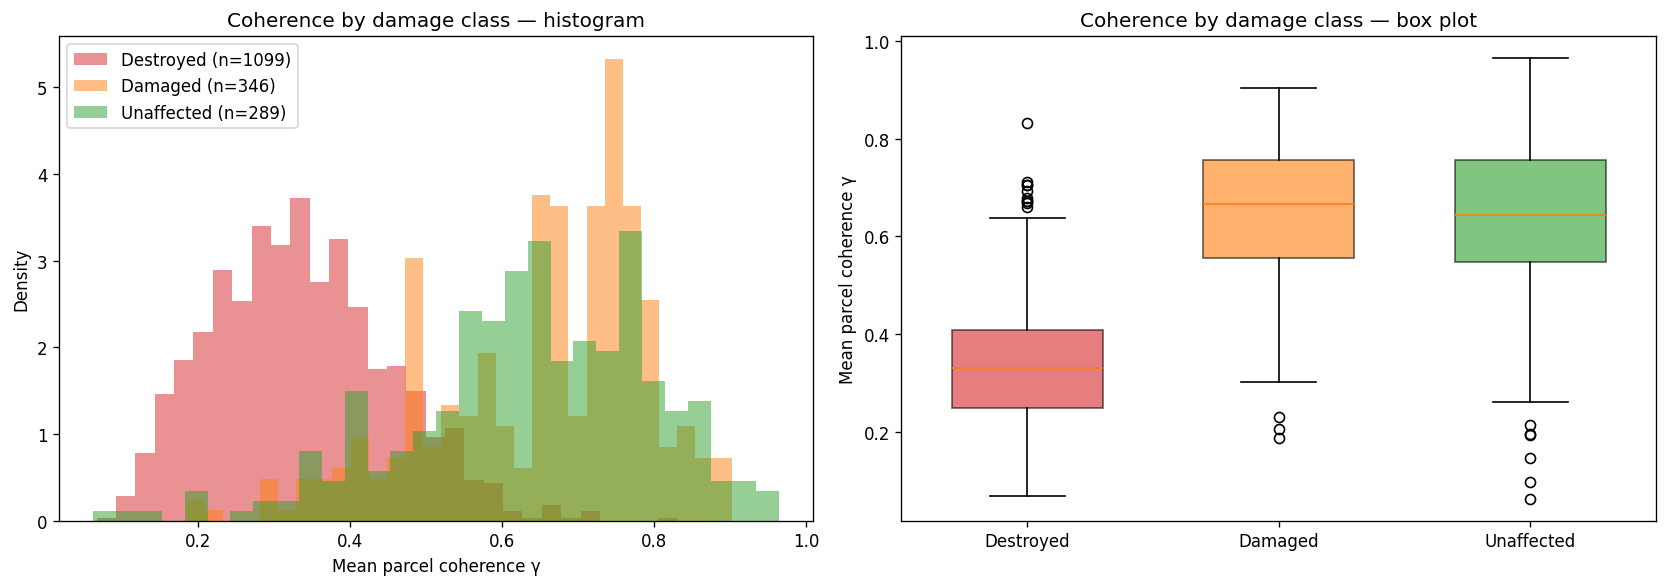

In [7]:
colors = {"Destroyed": "#d62728", "Damaged": "#ff7f0e", "Unaffected": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
for cond, color in colors.items():
    vals = labeled.loc[labeled["Condition"] == cond, "coh_mean"].dropna()
    axes[0].hist(vals, bins=30, alpha=0.5, color=color, label=f"{cond} (n={len(vals)})",
                 density=True, edgecolor="none")
axes[0].set_xlabel("Mean parcel coherence γ")
axes[0].set_ylabel("Density")
axes[0].set_title("Coherence by damage class — histogram")
axes[0].legend()

# Box plot
box_data = [labeled.loc[labeled["Condition"] == c, "coh_mean"].dropna() for c in colors]
bp = axes[1].boxplot(box_data, labels=list(colors.keys()), patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel("Mean parcel coherence γ")
axes[1].set_title("Coherence by damage class — box plot")

plt.tight_layout()
plt.show()

## 6 — Coherence map with ground truth overlay

/var/folders/zq/f6zc6fz576799p8z3wp0kl6h0000gn/T/ipykernel_84105/259058926.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")
/var/folders/zq/f6zc6fz576799p8z3wp0kl6h0000gn/T/ipykernel_84105/259058926.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


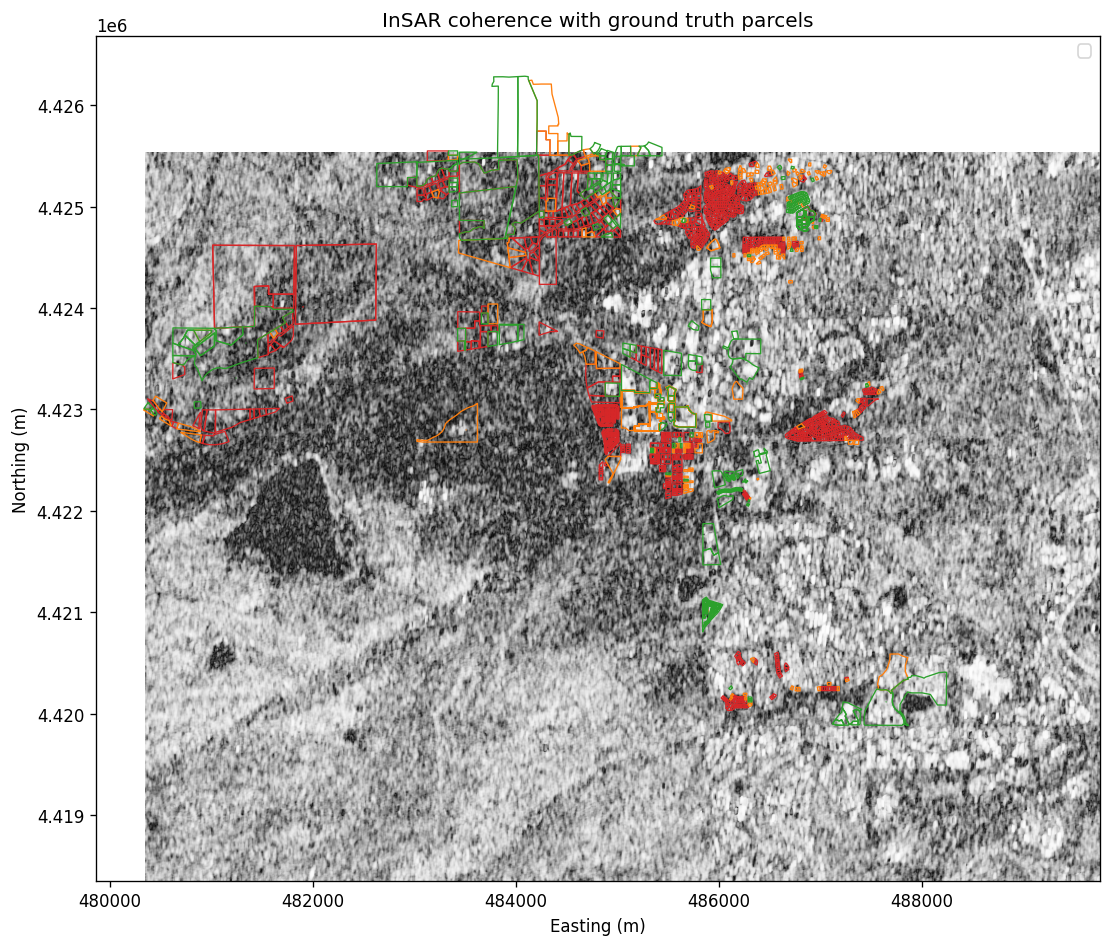

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Coherence background
extent = [x_coords[0], x_coords[-1], y_coords[-1], y_coords[0]]
ax.imshow(coherence, cmap="gray", vmin=0, vmax=1, extent=extent, aspect="auto")

# Parcel outlines coloured by damage class
for cond, color in colors.items():
    sub = labeled[labeled["Condition"] == cond]
    sub.plot(ax=ax, facecolor="none", edgecolor=color, linewidth=0.8, label=cond)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("InSAR coherence with ground truth parcels")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7 — Save coherence raster as COG for downstream use

In [9]:
out_path = Path("../data/processed/coherence_20211219_20211231.tif")
out_path.parent.mkdir(parents=True, exist_ok=True)

profile = {
    "driver": "GTiff",
    "dtype": "float32",
    "width": coherence.shape[1],
    "height": coherence.shape[0],
    "count": 1,
    "crs": CRS.from_epsg(32613),
    "transform": transform,
    "nodata": np.nan,
}

with rasterio.open(out_path, "w", **profile) as dst:
    dst.write(coherence, 1)

print(f"Saved: {out_path} ({out_path.stat().st_size / 1e6:.1f} MB)")

Saved: ../data/processed/coherence_20211219_20211231.tif (5.4 MB)


## Conclusions

**Coherence vs amplitude comparison:**

| Metric | Destroyed | Damaged | Unaffected | Separation |
|--------|-----------|---------|------------|------------|
| SAR VV amplitude Δ (dB) | −0.58 | −0.26 | −0.36 | ~0.3 dB (within noise) |
| **InSAR coherence γ** | **0.335 ± 0.116** | **0.651 ± 0.141** | **0.635 ± 0.160** | **~0.30 (10× noise)** |

**Key findings:**

1. **Destroyed parcels have dramatically lower coherence** (γ = 0.34) than
   Damaged (0.65) and Unaffected (0.64) — a separation of ~0.30 coherence units
   with std ~0.12–0.16, giving a signal-to-noise ratio of ~2–3×.

2. **Damaged ≈ Unaffected** in coherence (0.65 vs 0.64). This makes physical
   sense: "damaged" homes mostly retained their structure (roof/walls intact),
   so they still behave as coherent scatterers. Only total destruction causes
   the phase randomisation that drops coherence.

3. **InSAR coherence is a viable damage proxy** for this suburban fire. It
   cleanly separates Destroyed from non-Destroyed parcels, unlike amplitude
   change which showed no discrimination. This will be the primary SAR feature
   in the ML damage classifier.